# Homework 5: Local Search – Hill Climbing and Simulated Annealing
**CISC 440 – Artificial Intelligence**  
**Chapter 4 - Local Search Algorithms**

**Due:** See Canvas  
**Submission:** Upload this notebook to Canvas  

**Collaboration Policy:**  
You may work with **one partner (maximum 2 students)**.  
Submit **one notebook per group**.

# Name(s)

1.  Nikhil Jangir
2. Rudy Vergara

## Files Provided

You are provided with the following files:

- `Homework 5.ipynb`
- `search.py`
- `TwinCities Dataset.csv`
- `twin_cities_hub_scores.csv`

# Written Part

Local search algorithms are commonly used for **optimization problems** where the goal is to find a **good solution rather than an exact path**.

In this homework you will apply **Hill Climbing** and **Simulated Annealing** to a **hub placement problem**.

Imagine a logistics company wants to place a **distribution hub in the Twin Cities region**.

The hub location should balance:

- population demand  
- road accessibility  
- traffic congestion  
- distance to major demand zones  

The goal is to **find the best hub location** using local search.


# Question 1 — Local Search Concepts

Answer the following questions.


### 1. Hill Climbing

Explain why Hill Climbing may fail to find the global optimum.

**Answer**
    Hill climbing is a greedy algorithm, so it can commonly fail at finding the global optimum since it will not move to the next state if its value is less than the current state, which means it gets stuck in the local maximum. The global maximum, may come after a state that is lower in value than the current state, which is why the Hill climbing algorithm will not find the global maximum. 


### 2. Local Maximum

What is a **local maximum** in the context of hill climbing?

**Answer**
    The local maximum in the context of hill climbing is the 'peak' in value that is immediately reached as the highest value, meaning there may be an even bigger value later on (global maximum), but that is unreachable because the algorithm wouldn't accept getting there if there are lower values leading up to it. 


### 3. Simulated Annealing

Why can simulated annealing escape local maxima while hill climbing cannot?

**Answer**
    Hill climbing is Greedy, so therefore if it sees a state in front of it that is anything less than the one it is currently on, it will never move to it, even if there is an even greater value after. Simulated annealing can esccape this by occassionally accepting lower solutions using probability and temperature to escape the local maxima and keep searching. 



### 4. Cooling Schedule

Explain the role of the **temperature parameter** in simulated annealing.

**Answer**
    The temperature parameter acts as a way for the algorithm to know the risk factor and whether or not to take that risk. High T means the algorithm is much more likely to accept downward steps and allows it to explore the space without getting stuck in local maxima so easily. Lower Temps means the algorithm will be less likely to accept those downward steps and begins to behave more like Hill Climbing. 

### 5. TSP as a Local Search Problem

Why is the Traveling Salesperson Problem a good example of a local search optimization problem?

**Answer**
    TSP is a good example of a local search optimization problem because for a high number of cities, there are way too many possible routes, meaning we need to resort to optimization using local search by making small changes and swaps to optimize its path.





# Programming Part

In this programming exercise you will:

1. Load city data from **CSV files**
2. Automatically build a **Hub Graph**
3. Define a **Hub Placement Optimization Problem**
4. Define a **Traveling Salesperson Problem**
5. Solve both using:

- Hill Climbing
- Simulated Annealing
- Genetic Algorithm

Important:
Use the provided `search.py` for:

- `Problem`
- `hill_climbing`
- `simulated_annealing`
- `exp_schedule`

For the TSP genetic algorithm, do **not** use the generic GA functions from `search.py`.
Instead, implement your own:
- ordered crossover
- swap mutation
- TSP genetic algorithm runner

You may use these from search.py:
Problem, hill_climbing, simulated_annealing, exp_schedule
You must implement your own TSP genetic algorithm components.

## What You Must Implement

Students must implement the following components:

1. Load city data from CSV files
2. Implement the Euclidean distance function
3. Build the hub graph (citu_coordinates, K)
4. Implement the TwinCitiesHubProblem class
5. Implement the TwinCitiesTSPProblem class
6. Implement the genetic algorithm components:
   - ordered crossover(parent1, parent2)
   - swap mutation (route, pmt)
   - tsp_genetic_alogrithm(...)
7. Run experiments using:
   - hill climbing
   - simulated annealing
   - genetic algorithm

**Important:** For TSP, routes must remain valid permutations of the cities.
Your crossover and mutation operators must not create duplicate cities or omit cities.

# Dataset

Two CSV datasets are provided.

## Dataset 1 — City Coordinates

`TwinCities Dataset.csv`

| City | X | Y |
|-----|---|---|
| Downtown_StPaul | 60 | 90 |
| Midway | 50 | 75 |
| Maplewood | 85 | 75 |

These coordinates represent **relative map locations**.

## Dataset 2 — Hub Feature Scores

`twin_cities_hub_scores.csv`

| city | population_score | road_access | traffic |
|----|----|----|----|
| Downtown_StPaul | 10 | 9 | 9 |
| Midway | 8 | 8 | 6 |

These values represent **factors affecting hub quality**.

# Part A — Load the Data

Load both datasets using **pandas**.

```python
import pandas as pd

cities_df = pd.read_csv("TwinCities Dataset.csv")
scores_df = pd.read_csv("twin_cities_hub_scores.csv")

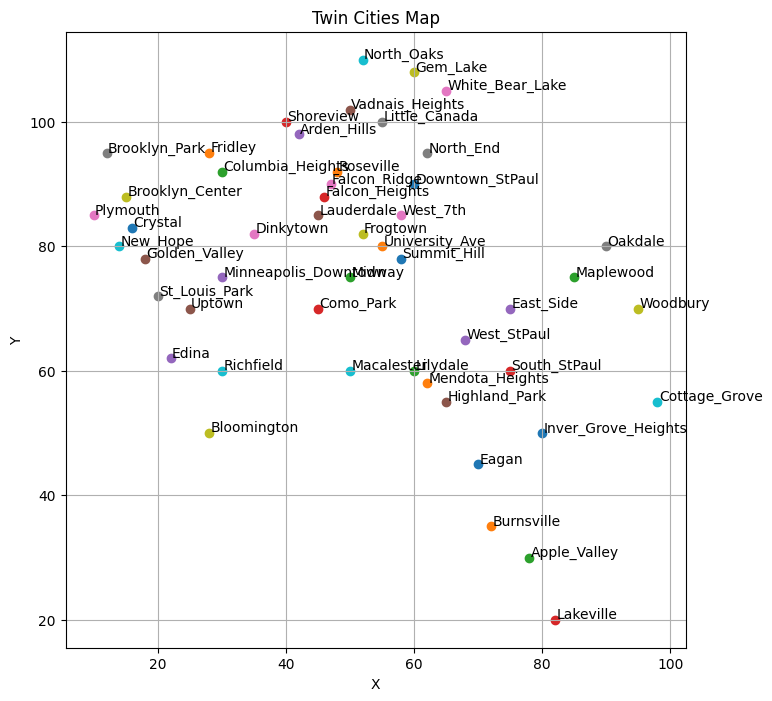

In [2]:
# ============================================================
# Visualization Functions
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt

cities = pd.read_csv("TwinCities Dataset.csv")

plt.figure(figsize=(8,8))

for _, row in cities.iterrows():
    plt.scatter(row["X"], row["Y"])
    plt.text(row["X"]+0.2, row["Y"]+0.2, row["City"])

plt.title("Twin Cities Map")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.show()


def plot_city_map(city_coordinates, title="Twin Cities Map from CSV"):
    plt.figure(figsize=(10, 8))

    for city, (x, y) in city_coordinates.items():
        plt.scatter(x, y)
        plt.text(x + 0.4, y + 0.4, city, fontsize=8)

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()


def plot_hub_graph(city_coordinates, hub_graph, title="HUB_GRAPH"):
    plt.figure(figsize=(10, 8))

    # Draw edges
    for city, neighbors in hub_graph.items():
        x1, y1 = city_coordinates[city]
        for neighbor in neighbors:
            x2, y2 = city_coordinates[neighbor]
            plt.plot([x1, x2], [y1, y2], alpha=0.5)

    # Draw nodes
    for city in hub_graph:
        x, y = city_coordinates[city]
        plt.scatter(x, y)
        plt.text(x + 0.4, y + 0.4, city, fontsize=8)

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()


def plot_tsp_route(route, city_coordinates, title="TSP Route"):
    xs = [city_coordinates[city][0] for city in route] + [city_coordinates[route[0]][0]]
    ys = [city_coordinates[city][1] for city in route] + [city_coordinates[route[0]][1]]

    plt.figure(figsize=(10, 8))
    plt.plot(xs, ys, marker="o")

    for city in route:
        x, y = city_coordinates[city]
        plt.text(x + 0.4, y + 0.4, city, fontsize=8)

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()

In [3]:
# ============================================================
# Function To run HUB and TSP problem
# ============================================================

import random

def random_route(k=12, seed=1):
    """
    Select k cities for the TSP experiment.
    """
    random.seed(seed)
    chosen = random.sample(list(CITY_COORDINATES.keys()), k)
    return tuple(chosen)


def run_hub_examples():
    print("\n=== HUB PLACEMENT PROBLEM ===")
    starts = ["Midway", "Maplewood", "Minneapolis_Downtown"]

    for start in starts:
        print(f"\nStart: {start}")

        problem = TwinCitiesHubProblem(start)
        hc_solution = hill_climbing(problem)
        print(f"Hill Climbing Result: {hc_solution}")
        print(f"Hub Score: {problem.value(hc_solution):.2f}")

        problem = TwinCitiesHubProblem(start)
        sa_solution = simulated_annealing(
            problem,
            schedule=exp_schedule(k=20, lam=0.01, limit=200)
        )
        print(f"Simulated Annealing Result: {sa_solution}")
        print(f"Hub Score: {problem.value(sa_solution):.2f}")


def run_tsp_examples():
    print("\n=== TSP PROBLEM ===")

    route = random_route(k=12, seed=7)
    tsp = TwinCitiesTSPProblem(route)

    print("\nInitial Route:")
    print_route(route)
    print(f"Initial distance: {tsp.route_length(route):.2f}")

    hc_solution = hill_climbing(tsp)
    print("\nHill Climbing Route:")
    print_route(hc_solution)
    print(f"Hill Climbing distance: {tsp.route_length(hc_solution):.2f}")

    sa_solution = simulated_annealing(
        tsp,
        schedule=exp_schedule(k=30, lam=0.01, limit=500)
    )
    print("\nSimulated Annealing Route:")
    print_route(sa_solution)
    print(f"Simulated Annealing distance: {tsp.route_length(sa_solution):.2f}")

    ga_solution = tsp_genetic_algorithm(
        tsp,
        pop_size=80,
        generations=400,
        pmut=0.2,
        seed=7
    )
    print("\nGenetic Algorithm Route:")
    print_route(ga_solution)
    print(f"Genetic Algorithm distance: {tsp.route_length(ga_solution):.2f}")

Create the following dictionaries:

- `CITY_COORDINATES`
- `POPULATION_SCORE`
- `ROAD_ACCESS`
- `TRAFFIC`

Example:

```python
CITY_COORDINATES["Midway"] = (50, 75)

In [ ]:
scores_df = pd.read_csv("twin_cities_hub_scores.csv")

CITY_COORDINATES = {row['City']: (row['X'], row['Y']) for _, row in cities.iterrows()}
POPULATION_SCORE = {row['city']: row['population_score'] for _, row in scores_df.iterrows()}
ROAD_ACCESS = {row['city']: row['road_access'] for _, row in scores_df.iterrows()}
TRAFFIC = {row['city']: row['traffic'] for _, row in scores_df.iterrows()}

print(f"Loaded {len(CITY_COORDINATES)} cities.")

## Part B — Distance Function

Implement the Euclidean distance function.
```python
distance(city1, city2)

#equation: 
sqrt((x1-x2)^2 + (y1-y2)^2)

In [ ]:
import math

def distance(city1, city2):
    x1, y1 = CITY_COORDINATES[city1]
    x2, y2 = CITY_COORDINATES[city2]
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# Test
print("Distance Midway to Downtown_StPaul:", distance("Midway", "Downtown_StPaul"))

## Part C — Build the Hub Graph

You must automatically construct the Hub Graph.

The graph represents possible local moves between hub locations.

Each city should be connected to its k nearest neighbors based on distance.

Use:
```python
K = 3

#Example graph structure:
HUB_GRAPH = {
    "Midway": ["University_Ave", "Como_Park", "Macalester"],
    "Maplewood": ["Oakdale", "Woodbury", "East_Side"]
}



### Task

Implement the function: build_hub_graph(city_coordinates, k)

Steps:

1. For each city
2. Compute distance to every other city
3. Sort neighbors by distance
4. Select the k closest neighbors

In [ ]:
def build_hub_graph(city_coordinates, k=3):
    hub_graph = {}
    all_cities = list(city_coordinates.keys())
    
    for city in all_cities:
        distances = []
        for other_city in all_cities:
            if city != other_city:
                d = distance(city, other_city)
                distances.append((d, other_city))
        
        # Sort neighbors by distance and pick the top k
        distances.sort()
        hub_graph[city] = [name for dist, name in distances[:k]]
        
    return hub_graph

# Create the graph with k = 3
HUB_GRAPH = build_hub_graph(CITY_COORDINATES, k=3)

#Test
print("Neighbors of Midway:", HUB_GRAPH["Midway"])

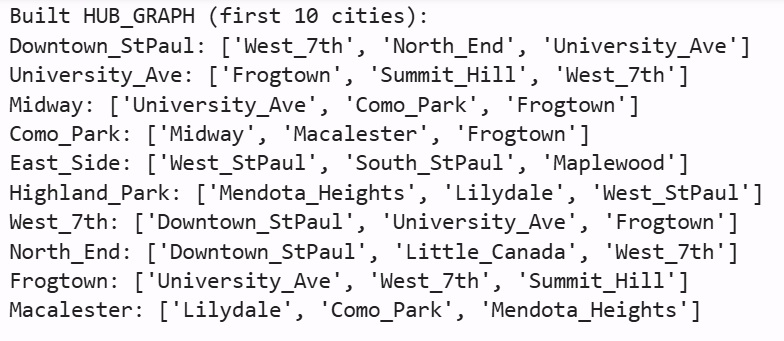

## Part D — Hub Placement Problem

Create a class:

`TwinCitiesHubProblem(Problem)`

### State
A city name.

### Actions
Neighbor cities from `HUB_GRAPH`.

### Result
Move to the selected neighbor city.



### Value Function for Hub Placement

The goal is to **maximize hub quality**.

Use the scoring function:

`value = - 3 * population_score + 2 * road_access - 2.5 * traffic - 0.15 * average_distance_to_demand_zones`


### Demand Zones
- Downtown_StPaul
- University_Ave
- Midway
- East_Side
- Minneapolis_Downtown
- Roseville
- Maplewood
- Woodbury


Higher value = **better hub location**.


In [ ]:
from search import Problem

class TwinCitiesHubProblem(Problem):
    def __init__(self, initial):
        #start at the city passed in
        super().__init__(initial)

    def actions(self, state):
        # Moves are the neighbors we defined already
        return HUB_GRAPH.get(state, [])

    def result(self, state, action):
        # Moving to a neighbor puts us in that neighbor city
        return action

    def value(self, state):
        # Quality = Population + Road Access - Traffic
        return POPULATION_SCORE[state] + ROAD_ACCESS[state] - TRAFFIC[state]

## Part E — Run Hill Climbing and Simulated Annealing for Hub Placement

Run **Hill Climbing** on the hub placement problem.

Use **three different starting cities**:

1. Midway
2. Maplewood
3. Minneapolis_Downtown

Print:

- Start city  
- Final hub location  
- Hub score  

### Example Output
Start: Midway

Hill Climbing Result: Midway

Hub Score: 21.85

Simulated Annealing Result: Frogtown

Hub Score: 19.99


Now run **Simulated Annealing** using the schedule:
    exp_schedule(k=20, lam=0.01, limit=200)

Print:

- Start city  
- Final hub location  
- Hub score  


In [ ]:
from search import hill_climbing, simulated_annealing, exp_schedule

starts = ["Midway", "Maplewood", "Minneapolis_Downtown"]

for start in starts:
    prob = TwinCitiesHubProblem(start)
    sol = hill_climbing(prob)
    print(f"Start: {start} -> Final: {sol} (Score: {prob.value(sol)})")

sch = exp_schedule(k=20, lam=0.01, limit=200)

for start in starts:
    prob = TwinCitiesHubProblem(start)
    sol = simulated_annealing(prob, schedule=sch)
    print(f"Start: {start} -> Final: {sol} (Score: {prob.value(sol)})")

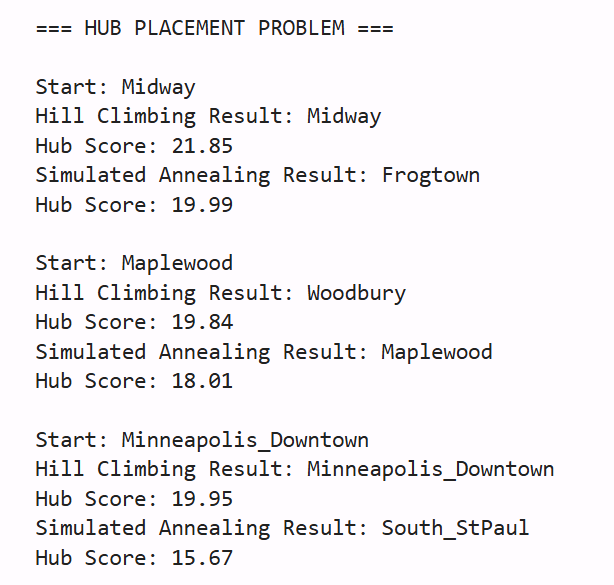

## Part F — Traveling Salesperson Problem (TSP)

In this part, you will use the same **Twin Cities coordinate dataset** to define a **Traveling Salesperson Problem (TSP)**.

The goal is to find a route that:

- visits every selected city **exactly once**
- returns to the **starting city**
- **minimizes the total route length**



### Step 1 — Select Cities for TSP

Select a subset of cities for the TSP experiment.

Use:
Use **12 cities**.


You may either:

- choose the **first 12 cities** from the dataset, or  
- **randomly select 12 cities**

Store the route as a **tuple or list**.

Example:

```python
initial_route = (
    "Downtown_StPaul",
    "University_Ave",
    "Midway",
    ...
)


In [ ]:
#use dictionary
tsp_cities = list(CITY_COORDINATES.keys())[:12]

print("Cities selected for TSP:")
print(tsp_cities)

### Step 2 — Define the TSP Problem

Create a class:

`TwinCitiesTSPProblem(Problem)`

#### State

A complete route (ordering of cities).

#### Actions

Define neighborhood operations that modify the route. You may use one or both of the following:

- swap(i, j)      swap two cities
- reverse(i, j)   reverse a segment of the route
- Result

Return the modified route after applying the selected action.

#### Value Function for TSP

The goal is to minimize total route length.

Because the search package maximizes value(state), define:

`value(state) = -1 * route_length(state)`

where:

`route_length(route)`

Computes the total Euclidean distance of the full closed tour.

A closed tour means the route must return to the starting city.

In [ ]:
class TwinCitiesTSPProblem(Problem):
    def __init__(self, initial):
        #'initial' state is the starting list of 12 cities
        super().__init__(tuple(initial))

    def actions(self, state):
        
        # We pick two cities in the route and swap them. 
    
        actions = []
        for i in range(len(state)):
            for j in range(i + 1, len(state)):
                actions.append((i, j))
        return actions

    def result(self, state, action):
        #Swaps the two cities at the indices defined in 'action'.
        new_route = list(state)
        i, j = action
        new_route[i], new_route[j] = new_route[j], new_route[i]
        return tuple(new_route)

    def route_length(self, state):
        """Calculates the total distance of the loop (returning to start)."""
        total = 0
        for i in range(len(state)):
            # Distance from current city to next city
            city_a = state[i]
            city_b = state[(i + 1) % len(state)] # connects the last city back to the first
            total += distance(city_a, city_b)
        return total

    def value(self, state):
     
        return -self.route_length(state)

## Part G — Run Hill Climbing and Simulated Annealing for TSP

Using your initial TSP route:

- Print the initial route
- Print the initial route distance
- Run Hill Climbing
- Print the final route and final distance
- Run Simulated Annealing
- Print the final route and final distance

Use the schedule:

`exp_schedule(k=30, lam=0.01, limit=500)`

Example Output

Initial distance: 412.57

Hill Climbing distance: 301.44

Simulated Annealing distance: 286.12

In [ ]:
# Create instance
tsp_prob = TwinCitiesTSPProblem(tsp_cities)

# 1 Initial State
print(f"Initial Route distance: {tsp_prob.route_length(tsp_prob.initial):.2f}")

# 2. Hill Climbing
hc_sol = hill_climbing(tsp_prob)
print(f"Hill Climbing distance: {tsp_prob.route_length(hc_sol):.2f}")

# 3.Simulated Annealing
# Using the schedule : k=30, lam=0.01, limit=500
tsp_sch = exp_schedule(k=30, lam=0.01, limit=500)
sa_sol = simulated_annealing(tsp_prob, schedule=tsp_sch)
print(f"Simulated Annealing distance: {tsp_prob.route_length(sa_sol):.2f}")

## Part H — Genetic Algorithm for TSP

In this part, you will implement a **Genetic Algorithm (GA)** to solve the Traveling Salesperson Problem.

Genetic Algorithms are inspired by **biological evolution** and use the following concepts:

- population
- selection
- crossover
- mutation
- generations

The goal is to evolve better routes over time.


### Step 1 — Initial Population

Create an **initial population of random routes**.

Each individual in the population should be a **permutation of the selected cities**.

Example population:

[
("Midway","Roseville","Maplewood",...),

("Roseville","Midway","Minneapolis_Downtown",...),

("Maplewood","Midway","Roseville",...)

]

Use a population size such as:

pop_size = 60


### Step 2 — Fitness Function

The fitness function evaluates the quality of each route.

Because shorter routes are better, define fitness as:

fitness(route) = -route_length(route)

This ensures that routes with **shorter distances have higher fitness**.

### Step 3 — Selection

Use **roulette-wheel selection** to choose parents for reproduction.

Parents with higher fitness should have **higher probability of selection**.

### Step 4 — Crossover

Because TSP routes are **permutations**, you must use a **permutation-safe crossover operator**.

Use **Ordered Crossover (OX)**:

1. Randomly select two cut points
2. Copy the segment from Parent 1
3. Fill the remaining cities using the order from Parent 2

Example:

Parent 1: A B C D E F
Parent 2: C F B A D E

Child after crossover preserves valid city order.

### Step 5 — Mutation

Apply **swap mutation** with a small probability.

Mutation operation:

swap(i, j)

This swaps two cities in the route.

Example:


A B C D E
→ swap(1,3)
A D C B E

Suggested mutation probability:


pmut = 0.2


### Step 6 — Run the Genetic Algorithm

Run the GA for multiple generations.

Suggested parameters:


population size = 80
generations = 400
mutation probability = 0.2


At each generation:

1. Evaluate fitness
2. Select parents
3. Apply crossover
4. Apply mutation
5. Form the next generation

Track the **best route found**.

### Step 7 — Print Results

Print:

- Best route found
- Total distance of that route

Example output:


Genetic Algorithm Route:
Midway -> Roseville -> Maplewood -> ... -> Midway

Genetic Algorithm distance: 278.43

**Important:** In TSP, each route must remain a valid permutation of the selected cities.
A route must not contain duplicate cities, and no city should be missing.
Your crossover and mutation operators must preserve valid routes.

```python
def tsp_genetic_algorithm(problem, pop_size=80, generations=400, pmut=0.2, seed=42):
    """
    Custom GA for permutation-based TSP.

    Args:
        problem: TwinCitiesTSPProblem
        pop_size: number of individuals
        generations: number of generations
        pmut: mutation probability
        seed: random seed

    Returns:
        best route found
    """
    random.seed(seed)

    cities = list(problem.initial)
    n = len(cities)

    # Initial population of random permutations
    population = [tuple(random.sample(cities, n)) for _ in range(pop_size)]

    best = max(population, key=problem.value)

    for gen in range(generations):
        raw_scores = [problem.value(ind) for ind in population]

        # Shift scores so fitness is positive
        min_score = min(raw_scores)
        fitness = [score - min_score + 1 for score in raw_scores]

        current_best = max(population, key=problem.value)
        if problem.value(current_best) > problem.value(best):
            best = current_best

        new_population = []
        for _ in range(pop_size):
            parent1 = random.choices(population, weights=fitness, k=1)[0]
            parent2 = random.choices(population, weights=fitness, k=1)[0]

            child = ordered_crossover(parent1, parent2)
            child = swap_mutation(child, pmut)

            new_population.append(child)

        population = new_population

    return best



In [ ]:
#Rudy
import random

def ordered_crossover(p1, p2):
    #permutation-safe crossover
    size = len(p1)
    a, b = sorted(random.sample(range(size), 2))

     Start with a section from Parent 1
    child = [None] * size
    child[a:b] = p1[a:b]
    
    #Fill rest from Parent 2 in the order they appear
    p2_remaining = [item for item in p2 if item not in child]
    
    current_pos = 0
    for i in range(size):
        if child[i] is None:
            child[i] = p2_remaining[current_pos]
            current_pos += 1
    return tuple(child)

def swap_mutation(route, pmut=0.2):
    """Step 5: Randomly swap two cities with a probability of pmut."""
    if random.random() < pmut:
        res = list(route)
        i, j = random.sample(range(len(res)), 2)
        res[i], res[j] = res[j], res[i]
        return tuple(res)
    return route

def tsp_genetic_algorithm(problem, pop_size=80, generations=400, pmut=0.2, seed=7):
    """Step 6: The main Genetic Algorithm loop."""
    random.seed(seed)
    cities = list(problem.initial)
    
    # Create Initial Population
    population = [tuple(random.sample(cities, len(cities))) for _ in range(pop_size)]
    
    best_overall = population[0]

    for gen in range(generations):
        #  Calculate Fitness -> (Value)
        # shift scores so all positive for the roulette selection
        scores = [problem.value(ind) for ind in population]
        min_s = min(scores)
        fitness = [s - min_s + 1 for s in scores]

        # Keep track of best found so far
        current_best = max(population, key=problem.value)
        if problem.value(current_best) > problem.value(best_overall):
            best_overall = current_best
        # Selection and Reproduce
        new_population = []
        for _ in range(pop_size):
            p1 = random.choices(population, weights=fitness, k=1)[0]
            p2 = random.choices(population, weights=fitness, k=1)[0]
            
            # Then, Crossover and Mutation
            child = ordered_crossover(p1, p2)
            child = swap_mutation(child, pmut)
            new_population.append(child)
        
        population = new_population

    return best_overall

# Run and Print Results
ga_sol = tsp_genetic_algorithm(tsp_prob)
print(f"Genetic Algorithm Route Distance: {tsp_prob.route_length(ga_sol):.2f}")

# Final Visual 
plot_tsp_route(ga_sol, CITY_COORDINATES, title="Final TSP Route (Genetic Algorithm)")

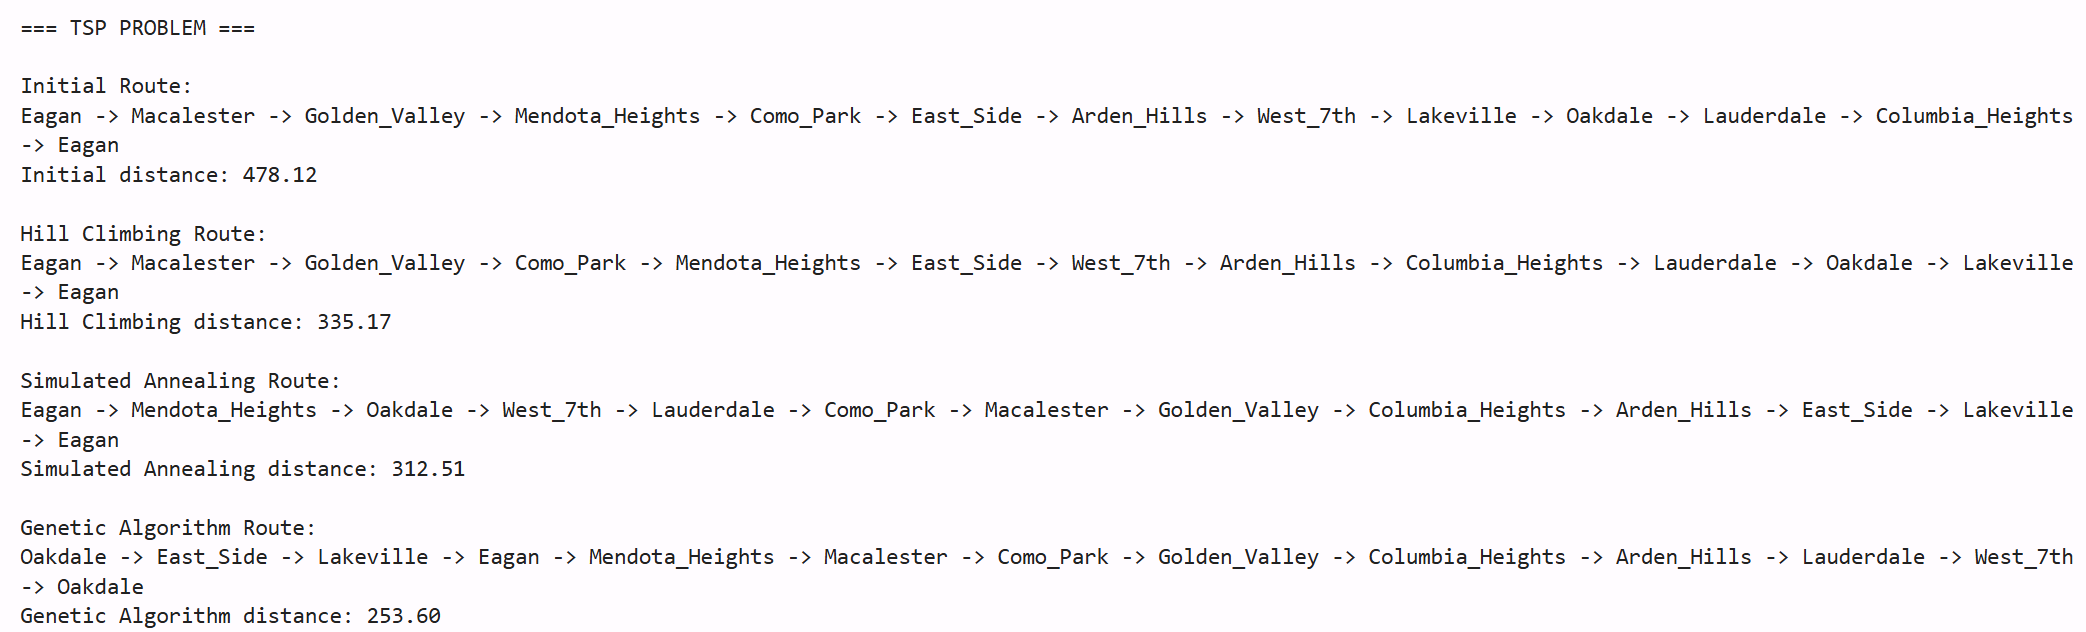

## Part I — Comparison Questions for Hub and TSP

Answer the following questions.

1. Did Hill Climbing always find the same hub location?

**Answer**

2. Did Simulated Annealing produce better hub solutions?

**Answer**

3. For the TSP problem, did the route distance improve after local search?

**Answer**

4. Did Simulated Annealing produce a shorter TSP route than Hill Climbing?

**Answer**

5. Why might simulated annealing perform better than hill climbing for TSP?

**Answer**

## Part J — Final Algorithm Comparison

Compare the three optimization methods used for TSP:

- Hill Climbing
- Simulated Annealing
- Genetic Algorithm

Answer the following questions.

1. Which algorithm produced the **shortest TSP route**?

**Answer**


2. Did Hill Climbing get stuck in a **local optimum**?

**Answer**


3. How did Simulated Annealing improve upon Hill Climbing?

**Answer**


4. Did the Genetic Algorithm produce a better solution than the other methods?

**Answer**


5. Why are Genetic Algorithms particularly useful for **permutation problems like TSP**?

**Answer**

### Visualize the TSP route using matplotlib.

Your visualization should:

• plot all cities  
• draw the TSP route  
• return to the starting city

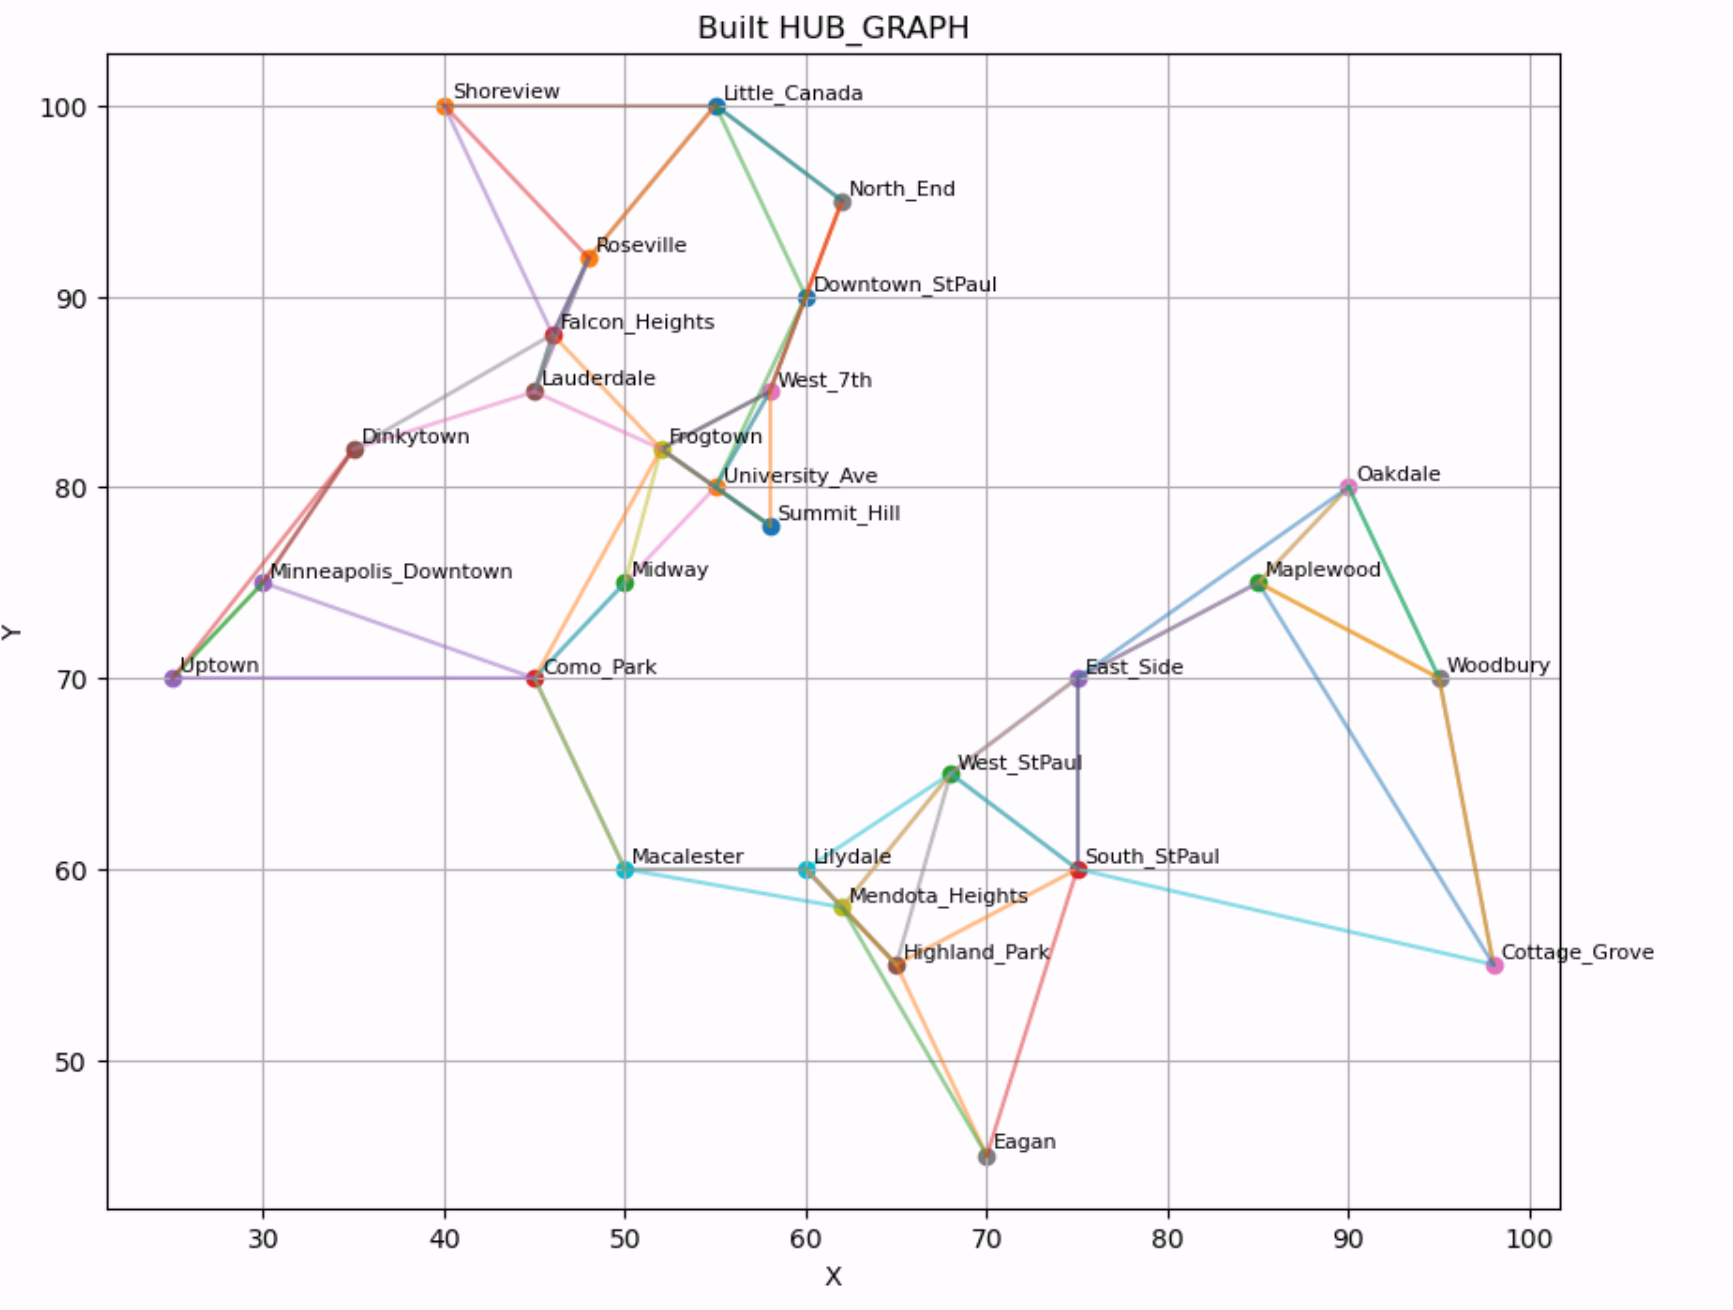

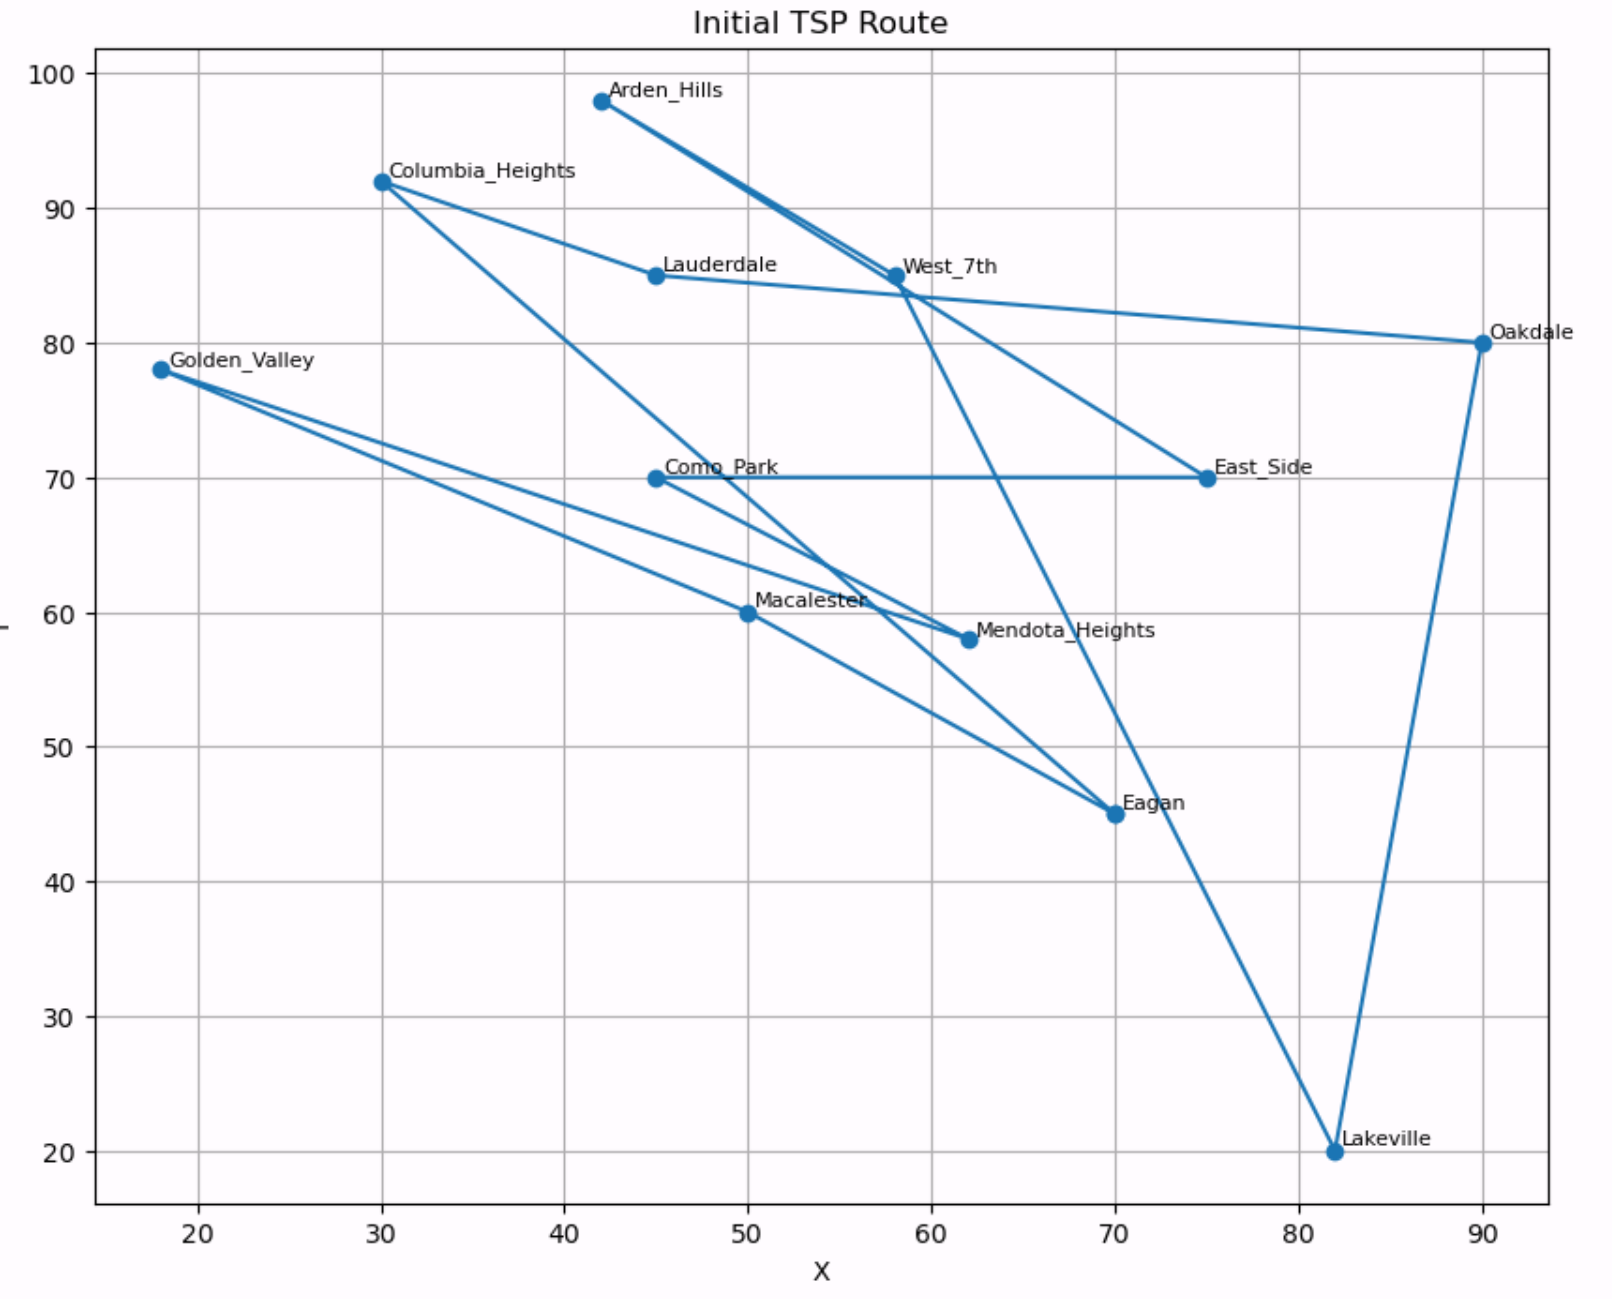

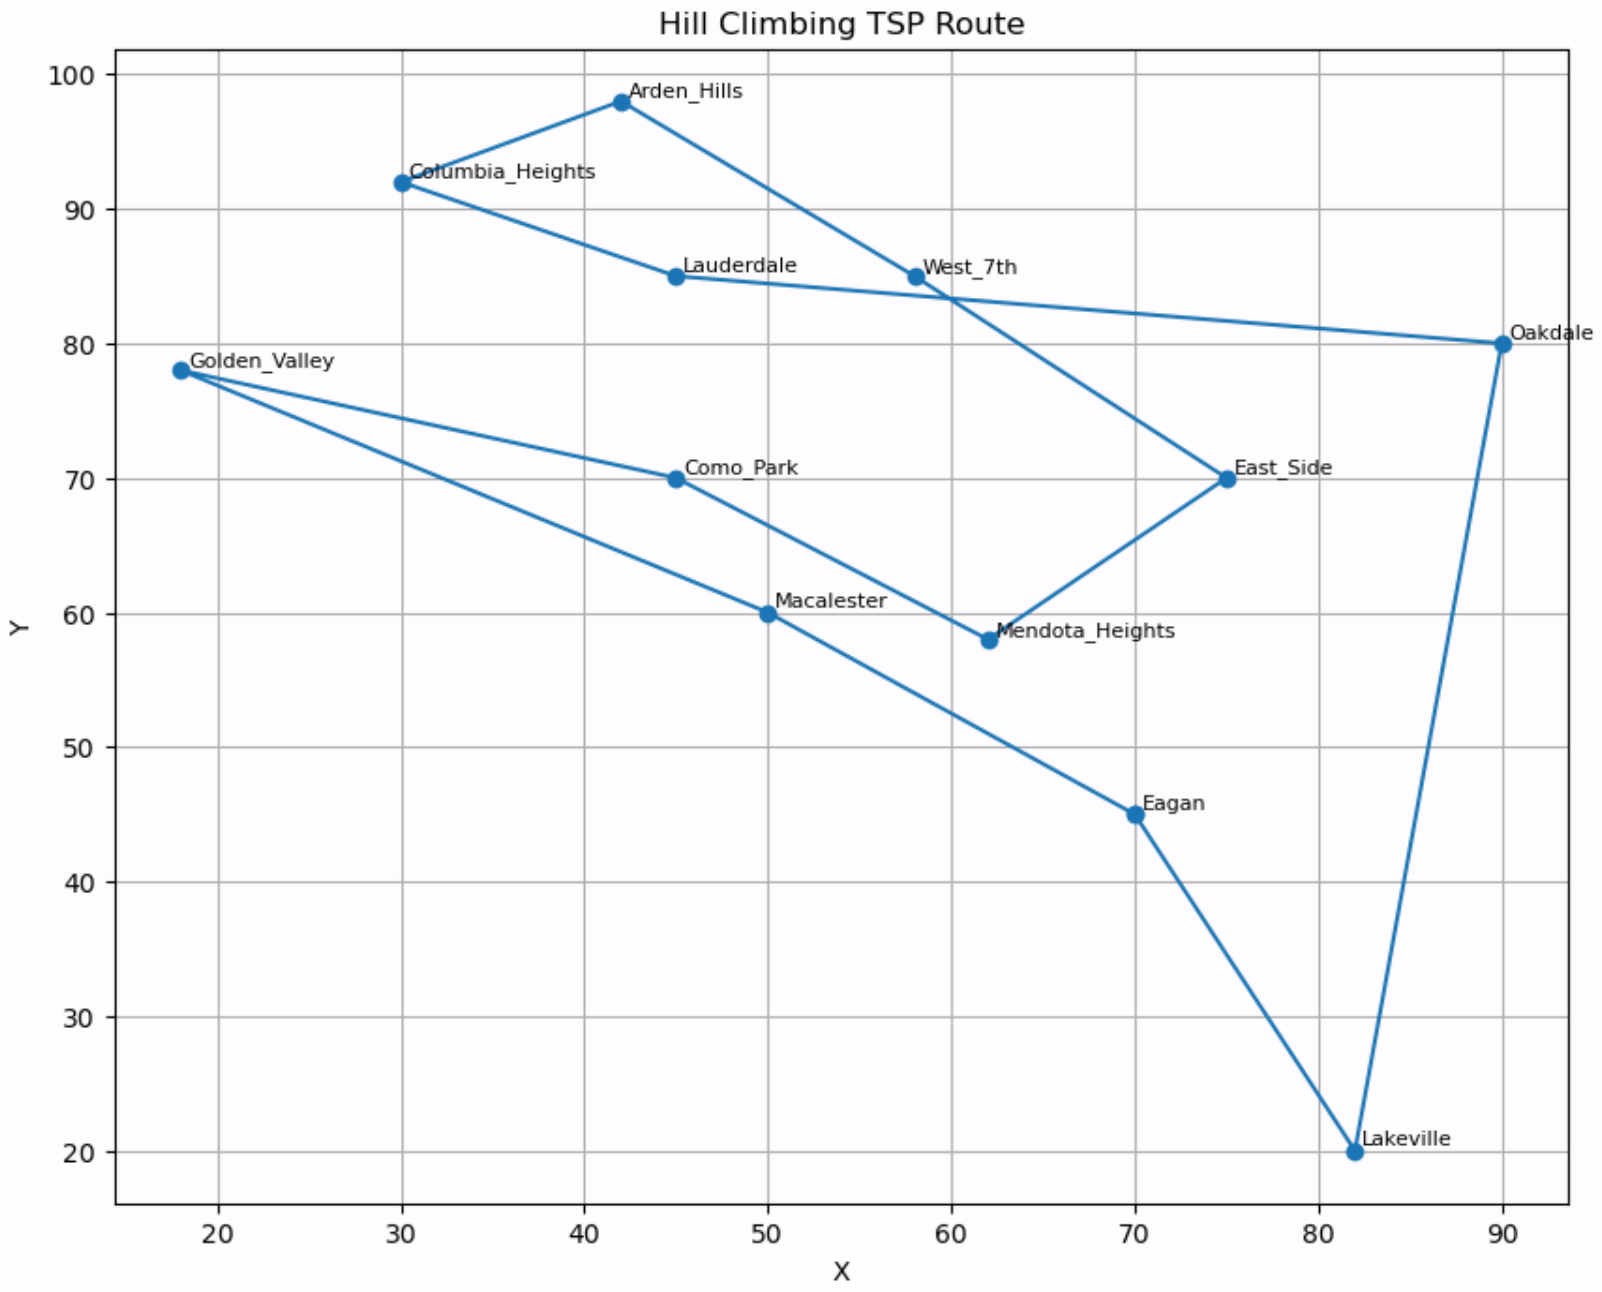

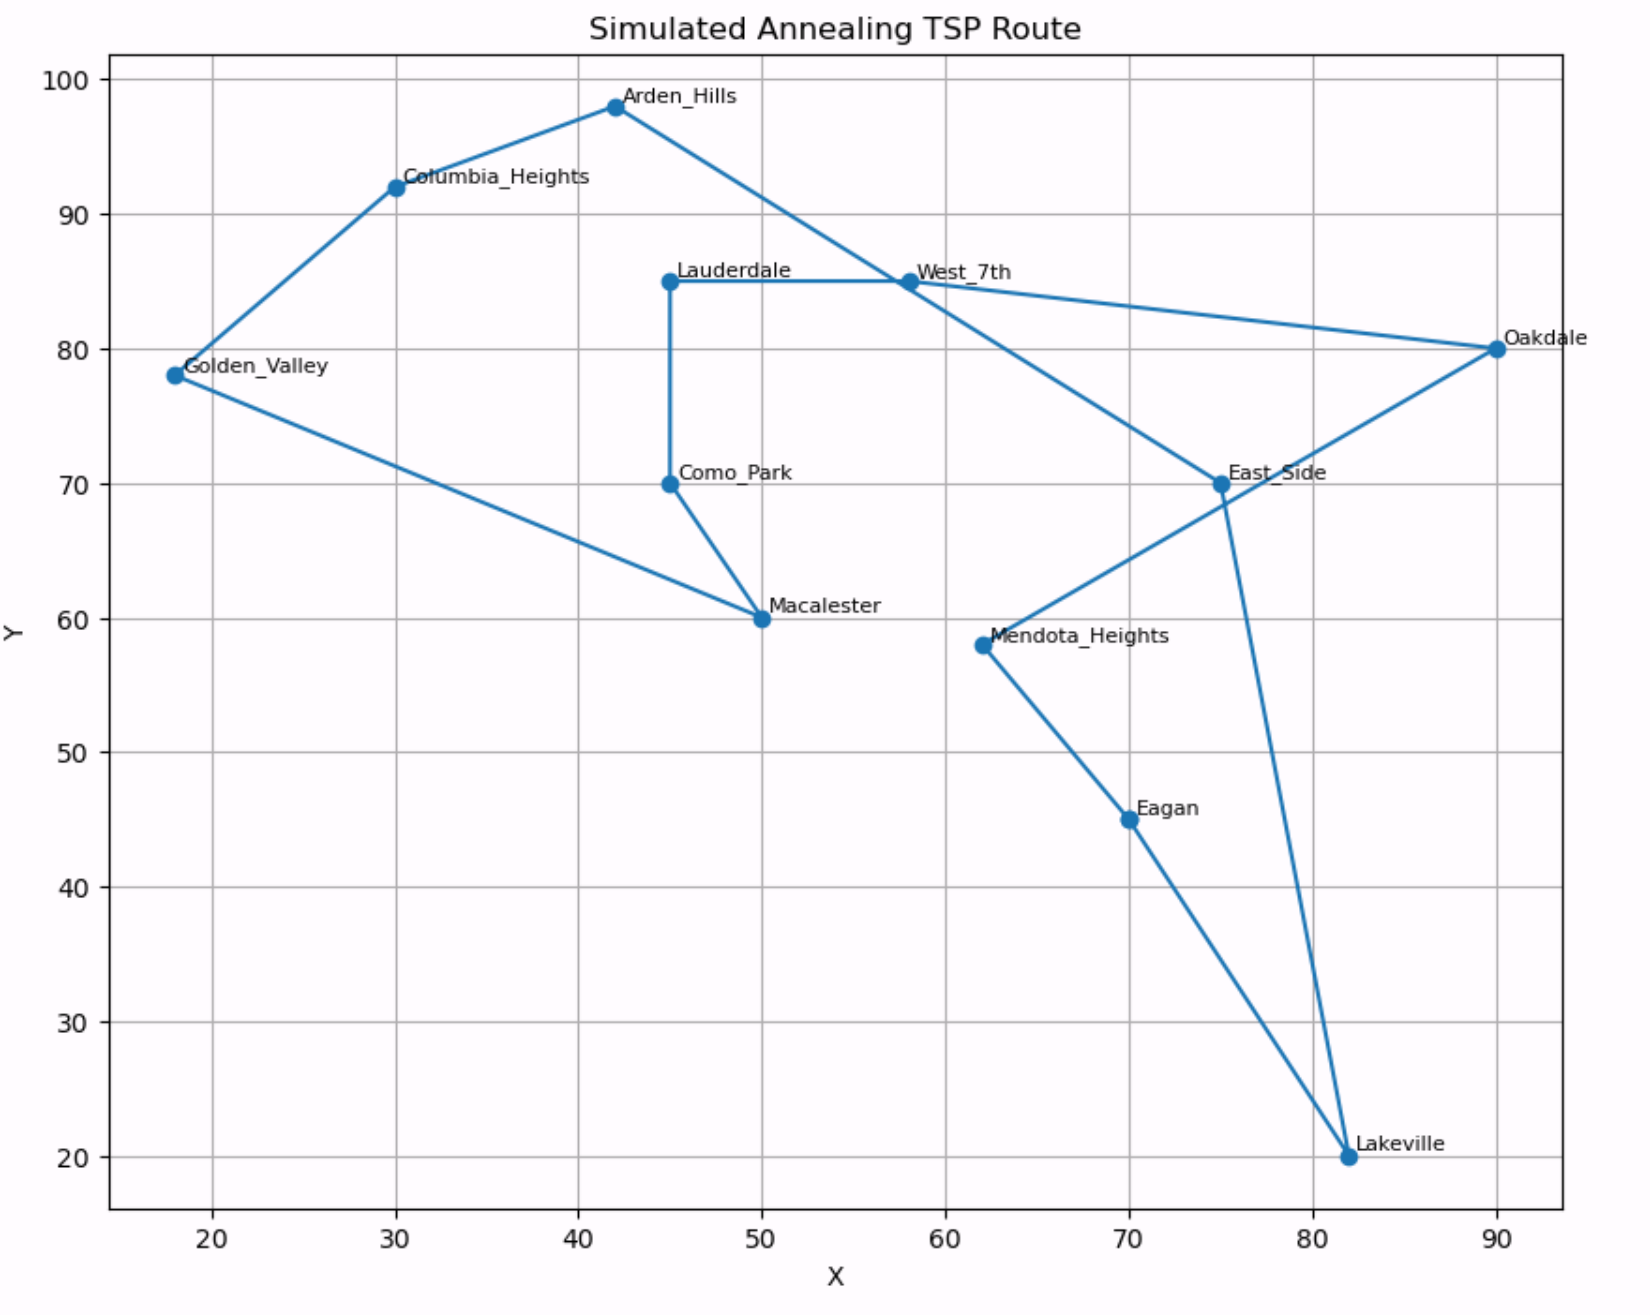

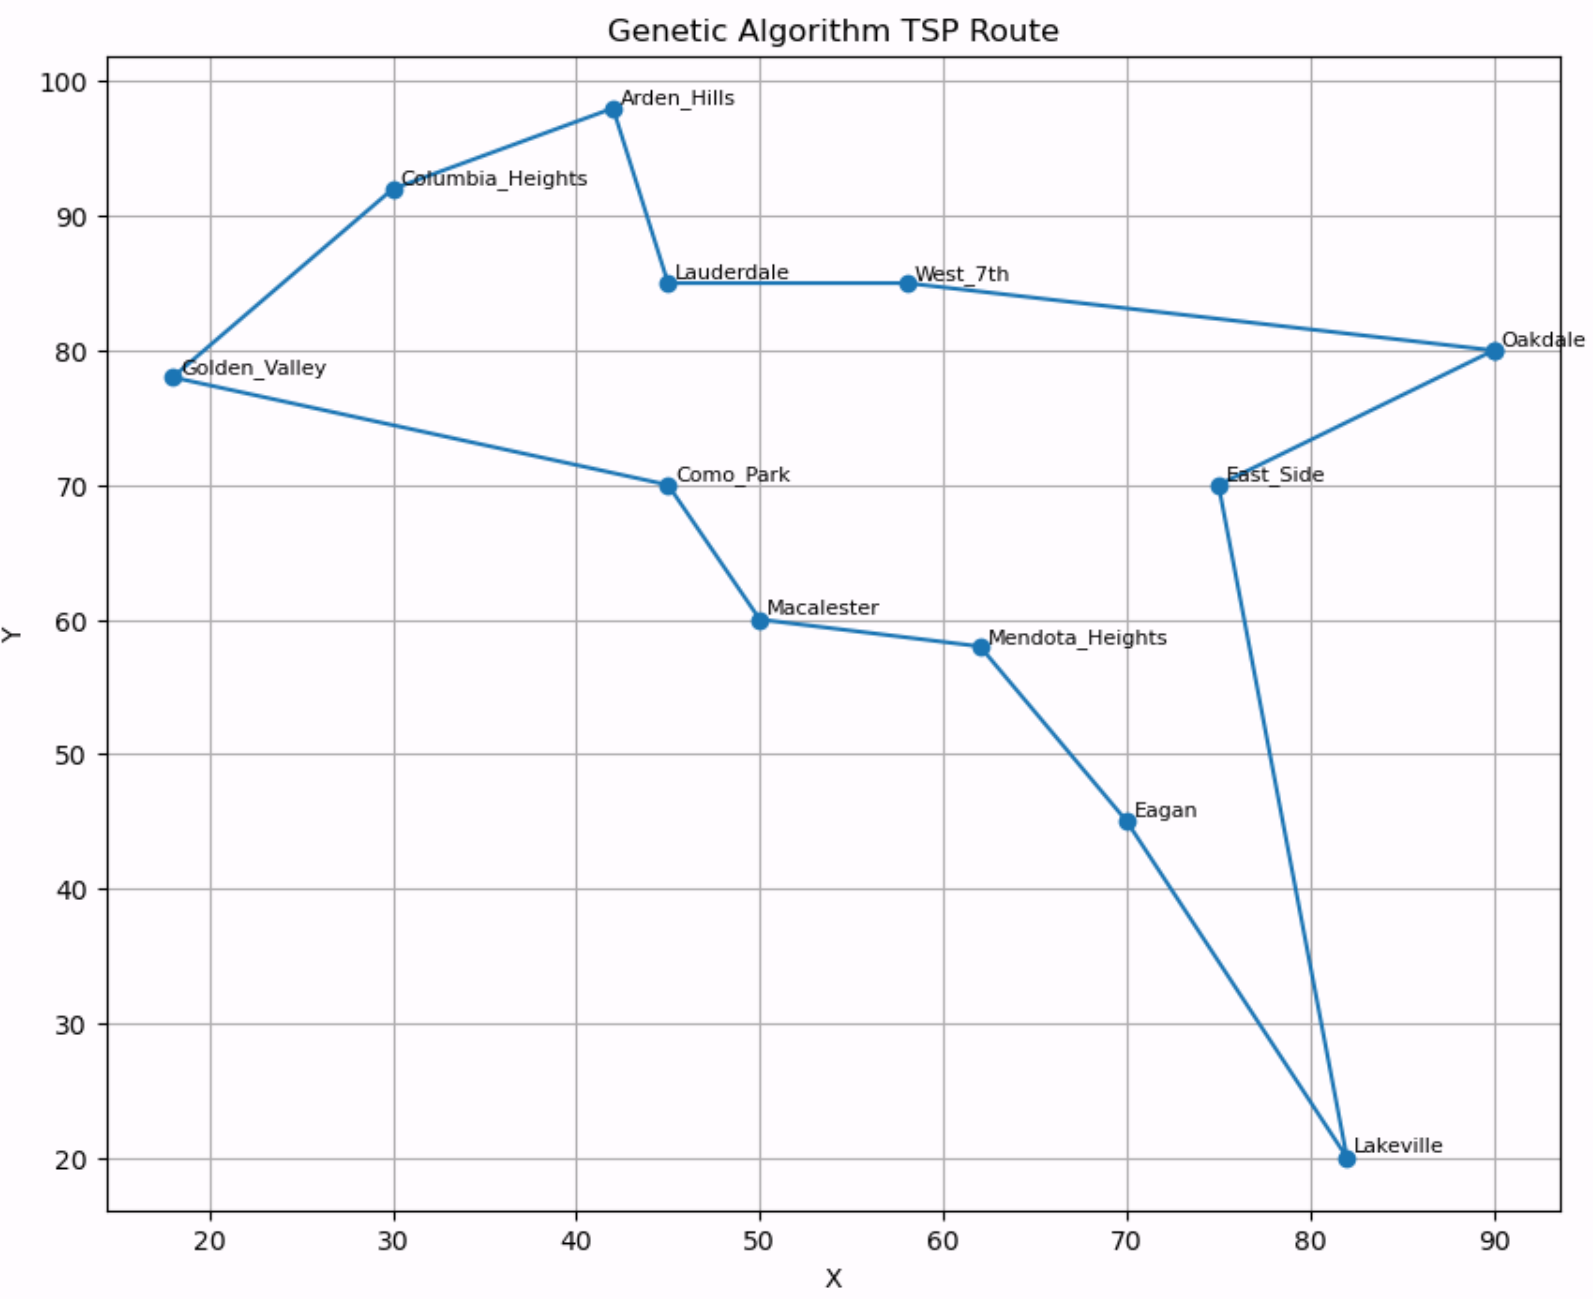